memo
- 미분의 연쇄법칙
- gradient vanishing
- 활성함수, 손실함수 (종류까지 상세하게)
- binary-crossentrophy
- 시그모이드 (0과 1 판별)
- 임계값 결정

In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [3]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("특성 수:", X_train.shape[1])

특성 수: 30


In [5]:
# sigmoid: 어떤 실수든 0~1 확률로 압축 (뉴런의 활성화함수)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 손실함수: Binary Cross-Entropy (예측확률이 정답에서 멀수록)
def bce_loss(y_true, y_pred):
    eps = 1e-9
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

In [6]:
n_features = X_train.shape[1]
w = np.zeros(n_features)
b = 0.0
lr = 0.1
epochs = 200

In [7]:
n = len(y_train)
history = []

for epoch in range(epochs):
    z = X_train @ w + b
    a = sigmoid(z)

    loss = bce_loss(y_train, a)
    history.append(loss)

    dz = a - y_train
    dw = X_train.T @ dz / n
    db = np.mean(dz)

    w -= lr * dw
    b -= lr * db

    if epoch % 40 == 0:
        print(f"epoch {epoch:3d} | loss {loss:.4f}")

epoch   0 | loss 0.6931
epoch  40 | loss 0.1367
epoch  80 | loss 0.1068
epoch 120 | loss 0.0940
epoch 160 | loss 0.0865


In [8]:
z_test = X_test @ w + b
proba = sigmoid(z_test)
pred = (proba >= 0.5).astype(int)

acc = np.mean(pred == y_test)
print(f"직접 만든 뉴런 정확도: {acc:.4f}")

직접 만든 뉴런 정확도: 0.9860


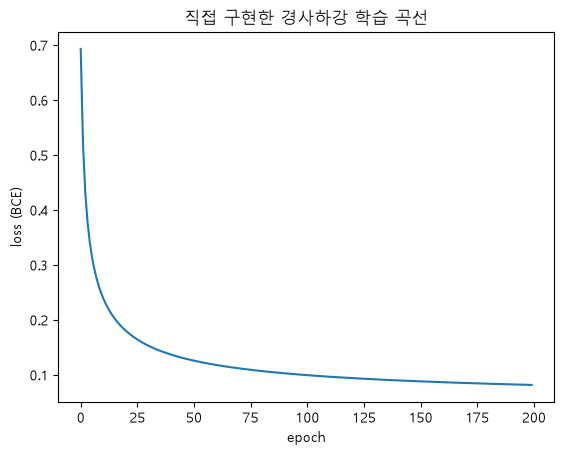

In [10]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False       # 마이너스(-) 깨짐 방지

plt.plot(history)
plt.xlabel('epoch'); plt.ylabel('loss (BCE)')
plt.title('직접 구현한 경사하강 학습 곡선')
plt.show()